# COM0418 Image Processing - Week 2 Laboratory
## NumPy Arrays, MATLAB Test Images, OpenCV I/O, Data Types, Display, and Bit-Plane Steganography

**Environment:** Anaconda Python / `imagepr_env` / JupyterLab  
**Main libraries:** NumPy, OpenCV, Matplotlib, Pillow

This notebook combines and updates the earlier **Lab 2 (NumPy arrays)** and **Lab 3 (image reading)** material. All image-processing examples now use the **MATLAB test images and MATLAB image-data directory used in the original laboratory material**.

### MATLAB test images used in this laboratory

- `cameraman.tif` - grayscale image; also used for binary images, data-type conversion, bit planes, and LSB steganography
- `baby.jpg` - true-color image read with OpenCV
- `sherlock.jpg` - true-color image read with Pillow for comparison
- `trees.tif` - indexed/palette color image

### Learning outcomes
By the end of this laboratory, you should be able to:

1. create, reshape, index, slice, copy, and modify NumPy arrays;
2. interpret an image as a NumPy array;
3. read **binary, grayscale, true-color/RGB, and indexed-color** images;
4. explain the **BGR vs RGB** issue in OpenCV and Matplotlib;
5. inspect and convert image data types safely;
6. display and save images with Matplotlib and OpenCV;
7. extract the eight bit planes of an 8-bit grayscale image;
8. use the least significant bit (LSB) plane for a simple **steganography** demonstration.

> **Important:** Steganography hides the existence of a message; it is not encryption. Use these techniques only on data you are permitted to modify.

## Student version - how to use this notebook

The two setup cells (imports and MATLAB test-image paths) are provided. Every later code cell is an **exercise cell**. Each exercise cell contains precise comments describing the operations to implement and the variable names needed by later sections.

**Workflow**
1. Run the two provided setup cells first.
2. Read the explanation above an exercise cell.
3. Implement the requested operations under `# Write your code below this line.`
4. Run the cell with **Shift+Enter** and inspect the output before moving to the next exercise.
5. Keep the requested variable names because later exercises depend on them.

The image examples use the same MATLAB sample images as the instructor notebook: `cameraman.tif`, `baby.jpg`, `sherlock.jpg`, and `trees.tif`.

## 0. Laboratory setup and MATLAB image directory

The course Anaconda environment has already been created. Start JupyterLab from the activated environment:

```text
conda activate imagepr_env
jupyter lab
```

The original laboratory files use MATLAB sample images located at:

```text
C:\Program Files\MATLAB\R2023b\toolbox\images\imdata
```

The notebook below uses this directory as its **primary source**. If your laboratory computer has a different MATLAB release, change only the `MATLAB_IMAGE_DIR` line, for example `R2024b` or `R2025a`.

For the instructor PDF generation only, a local fallback directory containing copies reconstructed from the original Lab 3 outputs is used when MATLAB is not installed. On the laboratory PCs, the real MATLAB files should be found first.

In [13]:
# Core libraries used throughout the lab
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

np.set_printoptions(linewidth=120)
print('OpenCV version :', cv2.__version__)
print('NumPy version  :', np.__version__)

OpenCV version : 4.10.0
NumPy version  : 2.2.6


### MATLAB test-image paths

The filenames below are taken directly from the earlier laboratory examples. A small helper function first checks the MATLAB installation directory and then uses the local fallback folder only when the MATLAB directory is unavailable.

This keeps the laboratory code close to the original MATLAB-based course material while allowing the instructor notebook to be rendered on a non-MATLAB computer.

In [14]:
MATLAB_IMAGE_DIR = Path(r'C:\Program Files\MATLAB\R2023b\toolbox\images\imdata')
LOCAL_FALLBACK_DIR = Path('matlab_test_images')

MATLAB_TEST_IMAGES = {
    'gray': 'cameraman.tif',
    'color_cv': 'baby.jpg',
    'color_pil': 'sherlock.jpg',
    'indexed': 'trees.tif',
}

def matlab_image_path(filename):
    """Return the real MATLAB image path when it exists; otherwise use fallback."""
    real_path = MATLAB_IMAGE_DIR / filename
    if real_path.exists():
        return real_path
    fallback_path = LOCAL_FALLBACK_DIR / filename
    if fallback_path.exists():
        return fallback_path
    raise FileNotFoundError(
        f'{filename} was not found. Check MATLAB_IMAGE_DIR: {MATLAB_IMAGE_DIR}'
    )

for key, filename in MATLAB_TEST_IMAGES.items():
    print(f'{key:10s}: {matlab_image_path(filename)}')

gray      : matlab_test_images/cameraman.tif
color_cv  : matlab_test_images/baby.jpg
color_pil : matlab_test_images/sherlock.jpg
indexed   : matlab_test_images/trees.tif


# 1. NumPy arrays for image processing

Digital images are stored and processed as arrays. In Python, OpenCV images are normally **NumPy `ndarray` objects**. Therefore, NumPy indexing and arithmetic are fundamental image-processing skills.

## 1.1 From Python lists to NumPy arrays

A Python list is a general container. A NumPy array stores values in a regular numeric structure, which allows fast vectorized operations.

In [15]:
# EXERCISE 01 - write your Python code below
#
# Required operations:
# 1. Create the Python list `mylist = [1, 2, 3, 4, 5]`.
# 2. Convert the list to a NumPy array named `myarray` with `np.array`.
# 3. Print the Python type of both objects, the contents of `myarray`, and `myarray.dtype`.
# 4. In one sentence, note why NumPy arrays are more suitable than lists for image matrices.
#
# Write your code below this line.


mylist = [1, 2, 3, 4, 5]
myarray = np.array(mylist)

print('type(mylist) :', type(mylist))
print('type(myarray):', type(myarray))
print('myarray      :', myarray)
print('myarray.dtype:', myarray.dtype)
print('NumPy arrays are better for image matrices because they store homogeneous numeric data in a fixed shape and support fast vectorized operations.')


type(mylist) : <class 'list'>
type(myarray): <class 'numpy.ndarray'>
myarray      : [1 2 3 4 5]
myarray.dtype: int64
NumPy arrays are better for image matrices because they store homogeneous numeric data in a fixed shape and support fast vectorized operations.


## 1.2 Array creation, shape, dimension, size, and reshape

The earlier NumPy lab used `arange`, `zeros`, `ones`, random arrays, and `reshape`. These operations map directly to creating masks, kernels, coordinate grids, and test images.

In [16]:
# EXERCISE 02 - write your Python code below
#
# Required operations:
# 1. Create `a` with integers 0-9 and `b` with the even integers 0-8 using `np.arange`.
# 2. Create a 3x5 `uint8` zero array named `z` and a 2x4 `float32` one array named `o`.
# 3. Set `np.random.seed(99)` and generate 10 random integers in [0,100) as `r`.
# 4. Print shape/dtype information, minimum, maximum, mean, argmin, argmax, and reshape `r` to 2x5.
#
# Write your code below this line.


a = np.arange(0, 10)
b = np.arange(0, 9, 2)

z = np.zeros((3, 5), dtype=np.uint8)
o = np.ones((2, 4), dtype=np.float32)

np.random.seed(99)
r = np.random.randint(0, 100, size=10)

print('a:', a)
print('b:', b)
print('z shape/dtype:', z.shape, z.dtype)
print('o shape/dtype:', o.shape, o.dtype)
print('r:', r)
print('r shape/dtype:', r.shape, r.dtype)
print('min:', r.min(), 'max:', r.max(), 'mean:', r.mean())
print('argmin:', r.argmin(), 'argmax:', r.argmax())
print('r reshaped 2x5:\n', r.reshape(2, 5))


a: [0 1 2 3 4 5 6 7 8 9]
b: [0 2 4 6 8]
z shape/dtype: (3, 5) uint8
o shape/dtype: (2, 4) float32
r: [ 1 35 57 40 73 82 68 69 52  1]
r shape/dtype: (10,) int64
min: 1 max: 82 mean: 47.8
argmin: 0 argmax: 5
r reshaped 2x5:
 [[ 1 35 57 40 73]
 [82 68 69 52  1]]


## 1.3 Matrix indexing and slicing

For an array `A`, NumPy uses **zero-based indexing**:

- `A[row, column]` selects one element;
- `A[:, c]` selects a complete column;
- `A[r, :]` selects a complete row;
- `A[r0:r1, c0:c1]` selects a rectangular region.

The ending index is excluded. Thus `0:4` selects indices 0, 1, 2, and 3.

In [17]:
# EXERCISE 03 - write your Python code below
#
# Required operations:
# 1. Create `mat = np.arange(0,100).reshape(10,10)`.
# 2. Print its shape and the values at `[0,1]` and `[4,6]`.
# 3. Using NumPy slicing, print the second column, third row, and top-left 4x4 block.
# 4. Remember that NumPy indexing starts from zero and the slice ending index is excluded.
#
# Write your code below this line.


mat = np.arange(0, 100).reshape(10, 10)

print('shape:', mat.shape)
print('mat[0,1]:', mat[0, 1])
print('mat[4,6]:', mat[4, 6])
print('second column:', mat[:, 1])
print('third row:', mat[2, :])
print('top-left 4x4:\n', mat[0:4, 0:4])


shape: (10, 10)
mat[0,1]: 1
mat[4,6]: 46
second column: [ 1 11 21 31 41 51 61 71 81 91]
third row: [20 21 22 23 24 25 26 27 28 29]
top-left 4x4:
 [[ 0  1  2  3]
 [10 11 12 13]
 [20 21 22 23]
 [30 31 32 33]]


## 1.4 Views, copies, and region modification

Slices are commonly used as **regions of interest (ROIs)**. A subtle NumPy behavior is that many slices are *views* of the original array. If you need an independent image or ROI, use `.copy()`.

In [18]:
# EXERCISE 04 - write your Python code below
#
# Required operations:
# 1. Create the 10x10 `uint8` array `base` from values 0-99.
# 2. Create `roi_view = base[0:4,0:4]` and `roi_copy = base[0:4,0:4].copy()`.
# 3. Set all values of `roi_view` to 0 and all values of `roi_copy` to 200.
# 4. Print `base` and `roi_copy` and explain from the output why a slice view and `.copy()` behave
# differently.
#
# Write your code below this line.


base = np.arange(0, 100, dtype=np.uint8).reshape(10, 10)

roi_view = base[0:4, 0:4]
roi_copy = base[0:4, 0:4].copy()

roi_view[:, :] = 0
roi_copy[:, :] = 200

print('base:\n', base)
print('roi_copy:\n', roi_copy)
print('roi_view shares memory with base, so changing it also changes base;')
print('roi_copy is independent, so setting it to 200 does not affect base.')


base:
 [[ 0  0  0  0  4  5  6  7  8  9]
 [ 0  0  0  0 14 15 16 17 18 19]
 [ 0  0  0  0 24 25 26 27 28 29]
 [ 0  0  0  0 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69]
 [70 71 72 73 74 75 76 77 78 79]
 [80 81 82 83 84 85 86 87 88 89]
 [90 91 92 93 94 95 96 97 98 99]]
roi_copy:
 [[200 200 200 200]
 [200 200 200 200]
 [200 200 200 200]
 [200 200 200 200]]
roi_view shares memory with base, so changing it also changes base;
roi_copy is independent, so setting it to 200 does not affect base.


# 2. Grayscale images

The MATLAB sample file **`cameraman.tif`** is an 8-bit grayscale image. OpenCV can read it directly as a 2-D array by using `cv2.IMREAD_GRAYSCALE` (or the value `0`).

In [19]:
# EXERCISE 05 - write your Python code below
#
# Required operations:
# 1. Use `matlab_image_path('cameraman.tif')` to obtain `gray_path`.
# 2. Read the image with `cv2.imread(..., cv2.IMREAD_GRAYSCALE)` into `gray`.
# 3. Check for a failed read (`gray is None`).
# 4. Print file path, object type, shape, dtype, minimum, and maximum pixel values.
#
# Write your code below this line.


gray_path = matlab_image_path('cameraman.tif')
gray = cv2.imread(str(gray_path), cv2.IMREAD_GRAYSCALE)

if gray is None:
    raise RuntimeError(f'Failed to read image: {gray_path}')

print('path :', gray_path)
print('type :', type(gray))
print('shape:', gray.shape)
print('dtype:', gray.dtype)
print('min  :', gray.min())
print('max  :', gray.max())


path : matlab_test_images/cameraman.tif
type : <class 'numpy.ndarray'>
shape: (256, 256)
dtype: uint8
min  : 7
max  : 253


## 2.1 Display the MATLAB `cameraman.tif` image with Matplotlib

For grayscale arrays, specify `cmap='gray'`. It is also good practice to fix the display range with `vmin=0, vmax=255` when comparing 8-bit images.

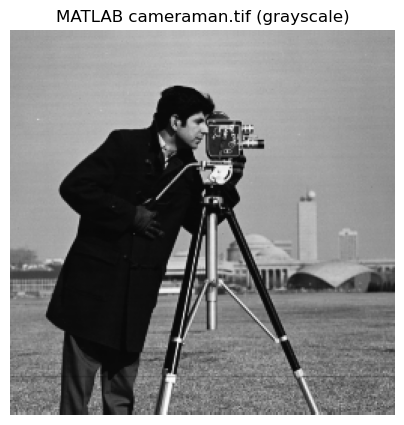

In [20]:
# EXERCISE 06 - write your Python code below
#
# Required operations:
# 1. Display `gray` with Matplotlib in a 5x5 figure.
# 2. Use `cmap='gray'` and explicitly set the 8-bit display range with `vmin=0, vmax=255`.
# 3. Add an informative title, turn axes off, and call `plt.show()`.
#
# Write your code below this line.


plt.figure(figsize=(5, 5))
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title('MATLAB cameraman.tif (grayscale)')
plt.axis('off')
plt.show()


## 2.2 Select and display a region of interest

The original Lab 3 example selected a region from `cameraman.tif` by NumPy slicing. Remember that Python indices start from zero and the ending index is excluded.

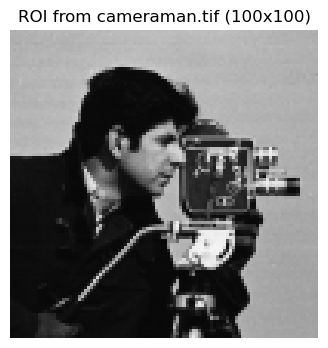

roi.shape: (100, 100)


In [21]:
# EXERCISE 07 - write your Python code below
#
# Required operations:
# 1. Extract a 100x100 ROI from `gray` using rows 25:125 and columns 75:175; store it as `roi`.
# 2. Display the ROI in grayscale with the correct 0-255 range.
# 3. Print `roi.shape` to verify the selected region size.
#
# Write your code below this line.


roi = gray[25:125, 75:175]

plt.figure(figsize=(4, 4))
plt.imshow(roi, cmap='gray', vmin=0, vmax=255)
plt.title('ROI from cameraman.tif (100x100)')
plt.axis('off')
plt.show()

print('roi.shape:', roi.shape)


# 3. Binary images from `cameraman.tif`

A logical binary image conceptually contains **0 and 1**. Image files and display routines often use **0 and 255** for black and white. Here we generate both representations from the MATLAB grayscale test image.

unique binary255: [  0 255]
unique binary01 : [0 1]


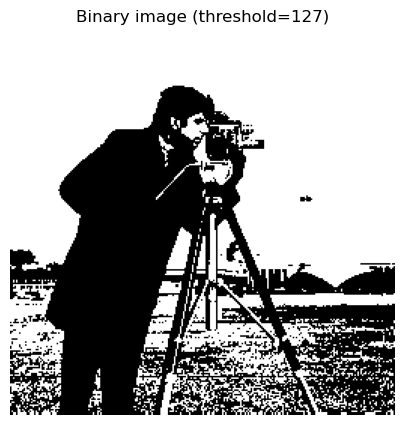

In [22]:
# EXERCISE 08 - write your Python code below
#
# Required operations:
# 1. Set `threshold_value = 127`.
# 2. Use `cv2.threshold` to generate `binary255`, whose pixels are 0 or 255.
# 3. Create `binary01` from `binary255` as a `uint8` array containing only 0 and 1.
# 4. Print unique values of both representations and display `binary01` with `vmin=0, vmax=1`.
#
# Write your code below this line.


threshold_value = 127
_, binary255 = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)
binary01 = (binary255 // 255).astype(np.uint8)

print('unique binary255:', np.unique(binary255))
print('unique binary01 :', np.unique(binary01))

plt.figure(figsize=(5, 5))
plt.imshow(binary01, cmap='gray', vmin=0, vmax=1)
plt.title(f'Binary image (threshold={threshold_value})')
plt.axis('off')
plt.show()


# 4. True-color images: OpenCV BGR vs RGB

The MATLAB test file **`baby.jpg`** is used for the OpenCV color example.

**Critical OpenCV detail:**

- `cv2.imread()` decodes a normal color image into **BGR** channel order.
- Matplotlib `plt.imshow()` expects **RGB** channel order.
- Therefore, an OpenCV BGR array displayed directly with Matplotlib has red and blue interchanged.

In [23]:
# EXERCISE 09 - write your Python code below
#
# Required operations:
# 1. Use `matlab_image_path('baby.jpg')` to obtain `baby_path`.
# 2. Read it with `cv2.imread(..., cv2.IMREAD_COLOR)` into `img_bgr` and check for a failed read.
# 3. Print shape and dtype.
# 4. Print pixel `[100,100]` and identify that the three returned values are in B, G, R order.
#
# Write your code below this line.


baby_path = matlab_image_path('baby.jpg')
img_bgr = cv2.imread(str(baby_path), cv2.IMREAD_COLOR)

if img_bgr is None:
    raise RuntimeError(f'Failed to read image: {baby_path}')

print('shape:', img_bgr.shape)
print('dtype:', img_bgr.dtype)
pixel = img_bgr[100, 100]
print('pixel [100,100]:', pixel)
print('Channel order is B, G, R -> B =', pixel[0], ', G =', pixel[1], ', R =', pixel[2])


shape: (3600, 2250, 3)
dtype: uint8
pixel [100,100]: [240 221 183]
Channel order is B, G, R -> B = 240 , G = 221 , R = 183


## 4.1 Correct the band order for Matplotlib

Use `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)` or reverse the last array axis with `image[:, :, ::-1]`. The comparison below makes the OpenCV/Matplotlib band-order issue visible.

cvtColor and axis reverse identical: True


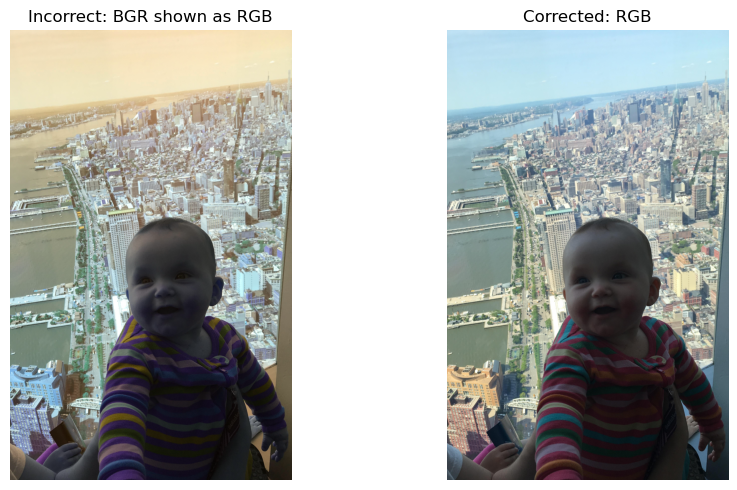

In [24]:
# EXERCISE 10 - write your Python code below
#
# Required operations:
# 1. Convert `img_bgr` to `img_rgb` using `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)`.
# 2. Create a second RGB version named `img_rgb_numpy` by reversing the last axis.
# 3. Verify with `np.array_equal` that the two conversion methods are identical.
# 4. Use two Matplotlib subplots to show the incorrect direct BGR display and the corrected RGB
# display.
#
# Write your code below this line.


img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb_numpy = img_bgr[:, :, ::-1]

print('cvtColor and axis reverse identical:', np.array_equal(img_rgb, img_rgb_numpy))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_bgr)
axes[0].set_title('Incorrect: BGR shown as RGB')
axes[0].axis('off')
axes[1].imshow(img_rgb)
axes[1].set_title('Corrected: RGB')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 4.2 Inspect the RGB channels

For a NumPy RGB array with shape `(rows, columns, 3)`:

- `[:,:,0]` is red,
- `[:,:,1]` is green,
- `[:,:,2]` is blue.

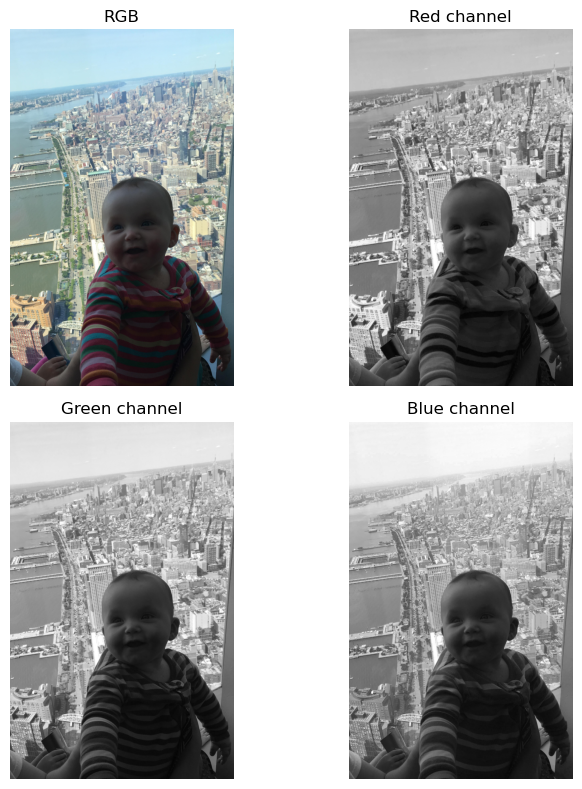

In [25]:
# EXERCISE 11 - write your Python code below
#
# Required operations:
# 1. From `img_rgb`, extract `R`, `G`, and `B` using channel indices 0, 1, and 2.
# 2. Create a 2x2 figure containing the RGB image and each channel displayed as a grayscale intensity
# image.
# 3. Use fixed 0-255 scaling for the individual channel images and turn axes off.
#
# Write your code below this line.


R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('RGB')
axes[0, 1].imshow(R, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Red channel')
axes[1, 0].imshow(G, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Green channel')
axes[1, 1].imshow(B, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Blue channel')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()


## 4.3 Read a MATLAB true-color test image with Pillow

The original Lab 3 also used **`sherlock.jpg`**. Pillow reads a normal JPEG into **RGB** order, so after conversion to a NumPy array it can be displayed directly by Matplotlib. This is different from OpenCV's default BGR order.

Pillow mode : RGB
NumPy type  : <class 'numpy.ndarray'>
shape       : (640, 960, 3)
dtype       : uint8


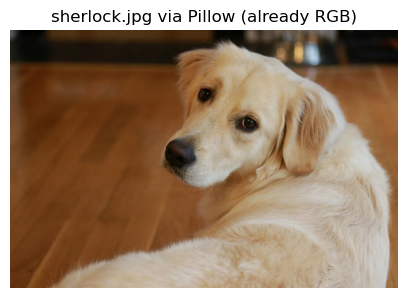

No BGR-to-RGB conversion is needed because Pillow loads JPEG color as RGB, which Matplotlib expects.


In [26]:
# EXERCISE 12 - write your Python code below
#
# Required operations:
# 1. Use `matlab_image_path('sherlock.jpg')` and open the file with `PIL.Image.open` as
# `sherlock_pil`.
# 2. Convert it to the NumPy array `sherlock_rgb` with `np.asarray`.
# 3. Print the Pillow mode, NumPy type, shape, and dtype.
# 4. Display it directly with Matplotlib and explain why no BGR-to-RGB conversion is required.
#
# Write your code below this line.


sherlock_path = matlab_image_path('sherlock.jpg')
sherlock_pil = Image.open(sherlock_path)
sherlock_rgb = np.asarray(sherlock_pil)

print('Pillow mode :', sherlock_pil.mode)
print('NumPy type  :', type(sherlock_rgb))
print('shape       :', sherlock_rgb.shape)
print('dtype       :', sherlock_rgb.dtype)

plt.figure(figsize=(5, 5))
plt.imshow(sherlock_rgb)
plt.title('sherlock.jpg via Pillow (already RGB)')
plt.axis('off')
plt.show()

print('No BGR-to-RGB conversion is needed because Pillow loads JPEG color as RGB, which Matplotlib expects.')


## 4.4 MATLAB vs OpenCV: reading color images

| Topic | MATLAB `imread` | OpenCV `cv2.imread` |
|---|---|---|
| Channel order | RGB | BGR by default |
| Array indexing | 1-based in MATLAB code | 0-based in Python |
| Typical 8-bit type | `uint8` | `numpy.uint8` |
| Color shape | rows x cols x 3 | rows x cols x 3 |
| Indexed image | can return index array + colormap | normally expands palette to BGR |
| Alpha channel | format-dependent | use `IMREAD_UNCHANGED` to keep alpha |

The underlying image file does not become “BGR”; OpenCV simply returns the decoded color channels in BGR order.

# 5. Indexed-color images: MATLAB `trees.tif`

The MATLAB sample file **`trees.tif`** is used as the indexed/palette image example. An indexed image stores an array of **palette indices** together with a **color map** rather than three color samples at every pixel.

OpenCV normally expands a palette image to a regular BGR array. Pillow is therefore more convenient when we want to inspect the palette representation itself.

In [27]:
# EXERCISE 13 - write your Python code below
#
# Required operations:
# 1. Open MATLAB `trees.tif` with Pillow as `indexed_pil`.
# 2. Print its Pillow mode and convert the stored pixel indices to `index_array` with `np.array`.
# 3. Read its palette using `getpalette()` and store it as `palette`.
# 4. Print the index-array shape/dtype, number of used index values, whether a palette exists, and the
# first six RGB triplets when available.
#
# Write your code below this line.


trees_path = matlab_image_path('trees.tif')
indexed_pil = Image.open(trees_path)

print('Pillow mode:', indexed_pil.mode)
index_array = np.array(indexed_pil)
palette = indexed_pil.getpalette()

print('index_array shape/dtype:', index_array.shape, index_array.dtype)
print('number of used index values:', len(np.unique(index_array)))
print('palette exists:', palette is not None)

if palette is not None:
    first_six = [tuple(palette[i:i+3]) for i in range(0, 18, 3)]
    print('first six RGB triplets:', first_six)


Pillow mode: P
index_array shape/dtype: (258, 350) uint8
number of used index values: 123
palette exists: True
first six RGB triplets: [(0, 0, 0), (16, 16, 8), (74, 8, 0), (0, 0, 255), (74, 16, 16), (99, 8, 24)]


## 5.1 Display the indexed image correctly

Convert the palette image to RGB before passing it to Matplotlib.

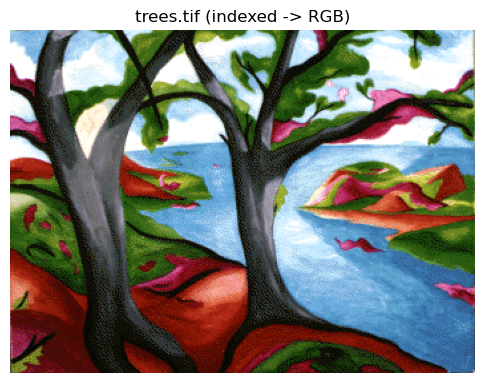

In [28]:
# EXERCISE 14 - write your Python code below
#
# Required operations:
# 1. Convert the palette image `indexed_pil` to RGB and then to NumPy array `indexed_rgb`.
# 2. Display the correctly converted `trees.tif` image using Matplotlib with an informative title and
# no axes.
#
# Write your code below this line.


indexed_rgb = np.asarray(indexed_pil.convert('RGB'))

plt.figure(figsize=(6, 5))
plt.imshow(indexed_rgb)
plt.title('trees.tif (indexed -> RGB)')
plt.axis('off')
plt.show()


## 5.2 What happens if OpenCV reads an indexed image?

OpenCV does not normally return the palette indices. It expands the palette into a 3-channel BGR image.

In [29]:
# EXERCISE 15 - write your Python code below
#
# Required operations:
# 1. Read `trees_path` with OpenCV using `cv2.IMREAD_COLOR` into `indexed_cv`.
# 2. Print its shape and dtype.
# 3. Compare this result with Pillow's index array and state what OpenCV returns instead of palette
# indices.
#
# Write your code below this line.


indexed_cv = cv2.imread(str(trees_path), cv2.IMREAD_COLOR)

if indexed_cv is None:
    raise RuntimeError(f'Failed to read image: {trees_path}')

print('OpenCV shape/dtype:', indexed_cv.shape, indexed_cv.dtype)
print('Pillow index_array shape/dtype:', index_array.shape, index_array.dtype)
print('OpenCV expands the palette image to a BGR color array instead of returning palette indices.')


OpenCV shape/dtype: (258, 350, 3) uint8
Pillow index_array shape/dtype: (258, 350) uint8
OpenCV expands the palette image to a BGR color array instead of returning palette indices.


# 6. Image data types and safe conversions

The array data type affects storage, arithmetic, and display.

Common image types:

- `uint8`: 0...255, one byte per channel;
- `uint16`: 0...65535, two bytes per channel;
- `float32` / `float64`: often used for processing; values may be normalized to 0...1.

Always inspect `shape`, `dtype`, and the numeric range before processing an unfamiliar image.

In [30]:
# EXERCISE 16 - write your Python code below
#
# Required operations:
# 1. Define a helper function `describe(name, image)` that prints shape, dtype, minimum, and maximum
# values.
# 2. Call the function for `gray` and `img_bgr`.
# 3. Use this function later whenever you need to verify the numeric representation of an image.
#
# Write your code below this line.


def describe(name, image):
    print(f'{name}: shape={image.shape}, dtype={image.dtype}, min={image.min()}, max={image.max()}')

describe('gray', gray)
describe('img_bgr', img_bgr)


gray: shape=(256, 256), dtype=uint8, min=7, max=253
img_bgr: shape=(3600, 2250, 3), dtype=uint8, min=0, max=255


## 6.1 Convert `uint8` to floating point correctly

`astype(np.float32)` changes the type but **does not automatically scale the numeric values**. For normalized floating-point images, divide by 255.

gray_float_raw range: 7.0 - 253.0
gray_float01 range  : 0.02745098 - 0.99215686


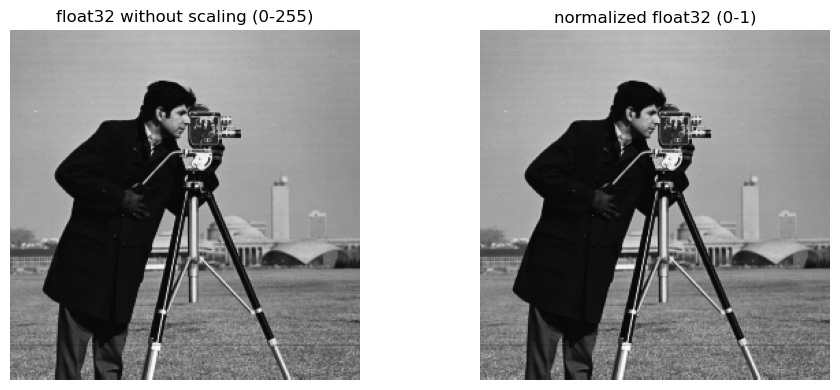

In [31]:
# EXERCISE 17 - write your Python code below
#
# Required operations:
# 1. Convert `gray` to `float32` without scaling as `gray_float_raw`.
# 2. Create normalized `gray_float01` by converting to `float32` and dividing by 255.0.
# 3. Print the numeric ranges of both arrays.
# 4. Display them side by side with matching display ranges (0-255 and 0-1) to show that dtype
# conversion and normalization are different operations.
#
# Write your code below this line.


gray_float_raw = gray.astype(np.float32)
gray_float01 = gray.astype(np.float32) / 255.0

print('gray_float_raw range:', gray_float_raw.min(), '-', gray_float_raw.max())
print('gray_float01 range  :', gray_float01.min(), '-', gray_float01.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray_float_raw, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('float32 without scaling (0-255)')
axes[0].axis('off')
axes[1].imshow(gray_float01, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('normalized float32 (0-1)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 6.2 Convert normalized floating point back to `uint8`

Use **scaling + rounding + clipping + conversion**. Direct `astype(np.uint8)` does not protect you from values below 0 or above 255.

In [32]:
# EXERCISE 18 - write your Python code below
#
# Required operations:
# 1. Convert normalized `gray_float01` back to `uint8` as `gray_back`.
# 2. Use multiply-by-255, rounding, clipping to [0,255], and `astype(np.uint8)`.
# 3. Use `np.array_equal` to verify whether the original `gray` image is reconstructed exactly.
#
# Write your code below this line.


gray_back = np.clip(np.round(gray_float01 * 255.0), 0, 255).astype(np.uint8)

print('exact reconstruction:', np.array_equal(gray, gray_back))
describe('gray_back', gray_back)


exact reconstruction: True
gray_back: shape=(256, 256), dtype=uint8, min=7, max=253


## 6.3 Convert the MATLAB grayscale image to 16-bit

The attached laboratory examples identify the MATLAB test-image directory and filenames but do not provide a separate 16-bit MATLAB sample filename. Therefore, we demonstrate **data-type conversion** using `cameraman.tif` itself.

A meaningful 8-bit-to-16-bit conversion can map `0...255` to `0...65535`. Multiplying by 257 performs this full-range mapping because `255 x 257 = 65535`.

gray: shape=(256, 256), dtype=uint8, min=7, max=253
gray_u16: shape=(256, 256), dtype=uint16, min=1799, max=65021
exact recovery: True


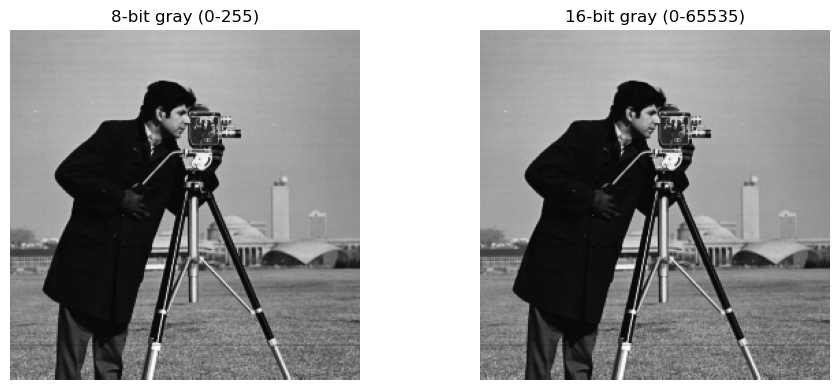

In [33]:
# EXERCISE 19 - write your Python code below
#
# Required operations:
# 1. Convert `gray` to `uint16` as `gray_u16` and map the full 8-bit range to 16-bit by multiplying by
# 257.
# 2. Use `describe` to compare `gray` and `gray_u16`.
# 3. Convert back to 8-bit as `gray_from_u16` and verify exact recovery.
# 4. Display the 8-bit and 16-bit versions side by side using their appropriate intensity ranges.
#
# Write your code below this line.


gray_u16 = gray.astype(np.uint16) * 257

describe('gray', gray)
describe('gray_u16', gray_u16)

gray_from_u16 = (gray_u16 // 257).astype(np.uint8)
print('exact recovery:', np.array_equal(gray, gray_from_u16))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('8-bit gray (0-255)')
axes[0].axis('off')
axes[1].imshow(gray_u16, cmap='gray', vmin=0, vmax=65535)
axes[1].set_title('16-bit gray (0-65535)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 6.4 NumPy overflow vs OpenCV saturated arithmetic

This distinction is important in image processing. `uint8` NumPy arithmetic can wrap around modulo 256, while functions such as `cv2.add` use saturation for 8-bit images.

**Implementation note:** for the scalar demonstration below, a `1 x 1` image array is used so `cv2.add` applies normal saturated image arithmetic.

In [34]:
# EXERCISE 20 - write your Python code below
#
# Required operations:
# 1. Create a 1x1 `uint8` image `p` containing 250.
# 2. Add 20 with ordinary NumPy `uint8` arithmetic and store the result as `numpy_result`.
# 3. Add 20 with `cv2.add` using an equally shaped `uint8` array and store it as `opencv_result`.
# 4. Print both results and explain wrap-around (NumPy) versus saturation at 255 (OpenCV).
#
# Write your code below this line.


p = np.array([[250]], dtype=np.uint8)

numpy_result = p + np.uint8(20)
opencv_result = cv2.add(p, np.full_like(p, 20))

print('numpy_result :', numpy_result)
print('opencv_result:', opencv_result)
print('NumPy uint8 wraps around (250+20 -> 14); OpenCV saturates at 255 (250+20 -> 255).')


numpy_result : [[14]]
opencv_result: [[255]]
NumPy uint8 wraps around (250+20 -> 14); OpenCV saturates at 255 (250+20 -> 255).


# 7. Displaying images in JupyterLab

## 7.1 Matplotlib - recommended for notebooks

Matplotlib works inline, supports subplots, titles, axes, and colormaps, and is therefore convenient for laboratory reports.

Remember:

- grayscale: `plt.imshow(gray, cmap='gray')`;
- OpenCV color: convert BGR to RGB first;
- use `plt.axis('off')` for a clean image-only view.

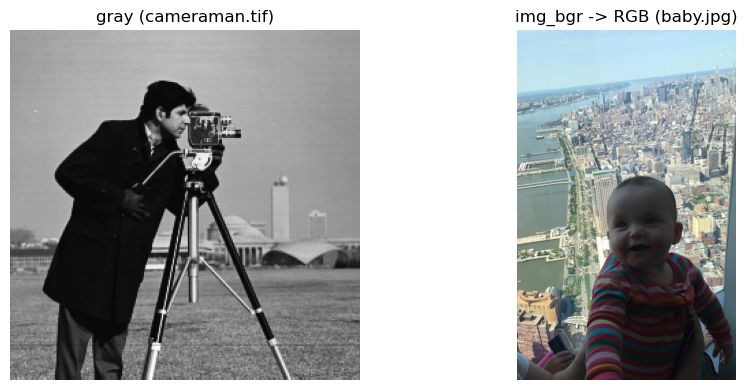

In [35]:
# EXERCISE 21 - write your Python code below
#
# Required operations:
# 1. Create a two-panel Matplotlib figure.
# 2. Display `gray` correctly as grayscale in the first panel.
# 3. Display `img_bgr` correctly in the second panel by converting BGR to RGB before `plt.imshow`.
# 4. Add titles, remove axes, and use `tight_layout`.
#
# Write your code below this line.


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('gray (cameraman.tif)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title('img_bgr -> RGB (baby.jpg)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 7.2 OpenCV GUI display (`cv2.imshow`)

On a local desktop Python installation, OpenCV can open a separate GUI window. In JupyterLab this may depend on the operating system and GUI backend, so Matplotlib is usually more reliable inside the notebook.

The code below is intentionally disabled during automatic execution. Change `RUN_OPENCV_GUI` to `True` if you want to test it on a lab PC.

In [36]:
# EXERCISE 22 - write your Python code below
#
# Required operations:
# 1. Set `RUN_OPENCV_GUI = False` initially.
# 2. Inside an `if RUN_OPENCV_GUI:` block, show `img_bgr` with `cv2.imshow`, wait for a key with
# `cv2.waitKey(0)`, and close windows with `cv2.destroyAllWindows()`.
# 3. Only change the flag to True on a lab PC where GUI windows are supported.
#
# Write your code below this line.


RUN_OPENCV_GUI = False

if RUN_OPENCV_GUI:
    cv2.imshow('img_bgr', img_bgr)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
else:
    print('OpenCV GUI skipped. Set RUN_OPENCV_GUI = True on a lab PC with display support.')


OpenCV GUI skipped. Set RUN_OPENCV_GUI = True on a lab PC with display support.


## 7.3 Writing images with OpenCV

`cv2.imwrite()` expects the array in OpenCV channel order. If your working image is RGB, convert it back to BGR before writing with OpenCV.

In [37]:
# EXERCISE 23 - write your Python code below
#
# Required operations:
# 1. Create output folder `week2_lab_output` using `Path` and `mkdir(exist_ok=True)`; store it as
# `OUTPUT_DIR`.
# 2. Convert `img_rgb` back to BGR as `out_bgr` because `cv2.imwrite` expects OpenCV channel order.
# 3. Write the image as `baby_written_by_opencv.png` and print whether the write succeeded.
#
# Write your code below this line.


OUTPUT_DIR = Path('week2_lab_output')
OUTPUT_DIR.mkdir(exist_ok=True)

out_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
out_path = OUTPUT_DIR / 'baby_written_by_opencv.png'
ok = cv2.imwrite(str(out_path), out_bgr)

print('write succeeded:', ok)
print('saved to:', out_path.resolve())


write succeeded: True
saved to: /Users/onurakyuz/Documents/GitHub/COM0418-ImageProcessing/Lab 2/week2_lab_output/baby_written_by_opencv.png


# 8. Bit planes of MATLAB `cameraman.tif`

Each 8-bit pixel can be written as:

`p = b7*2^7 + b6*2^6 + ... + b1*2^1 + b0*2^0`

where each `bk` is 0 or 1.

- **Bit 7** is the most significant bit (MSB).
- **Bit 0** is the least significant bit (LSB).

The upper bit planes contain much of the visually important structure. The lower planes often look noise-like, which is why the LSB can be used for simple data hiding.

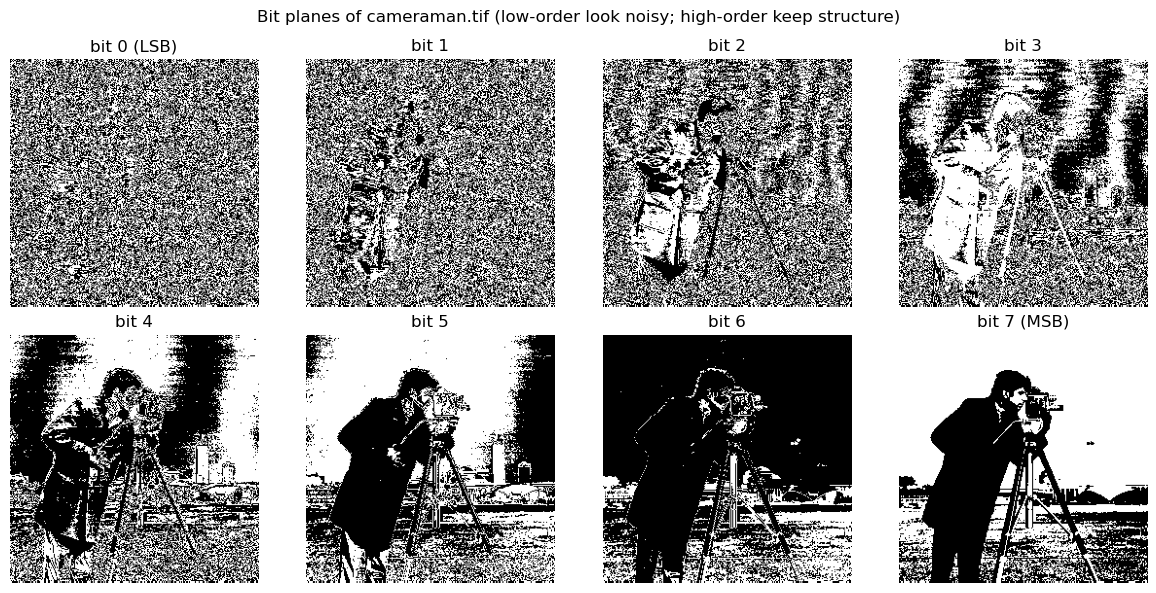

In [38]:
# EXERCISE 24 - write your Python code below
#
# Required operations:
# 1. Extract all eight bit planes of the 8-bit grayscale image `gray` using bit shifts and bitwise
# AND; store them in list `bit_planes`.
# 2. Display planes 0-7 in a 2x4 layout using grayscale display with range 0-1.
# 3. Label bit 0 as LSB and bit 7 as MSB, then compare how much visual structure appears in low- and
# high-order planes.
#
# Write your code below this line.


bit_planes = [((gray >> i) & 1).astype(np.uint8) for i in range(8)]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    label = f'bit {i}'
    if i == 0:
        label += ' (LSB)'
    elif i == 7:
        label += ' (MSB)'
    ax.imshow(bit_planes[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(label)
    ax.axis('off')

plt.suptitle('Bit planes of cameraman.tif (low-order look noisy; high-order keep structure)')
plt.tight_layout()
plt.show()


## 8.1 Reconstruct the image from selected bit planes

A bit plane contributes its binary values multiplied by `2^k`. We can reconstruct the image from all planes or intentionally keep only the most significant planes.

all-plane reconstruction equals gray: True


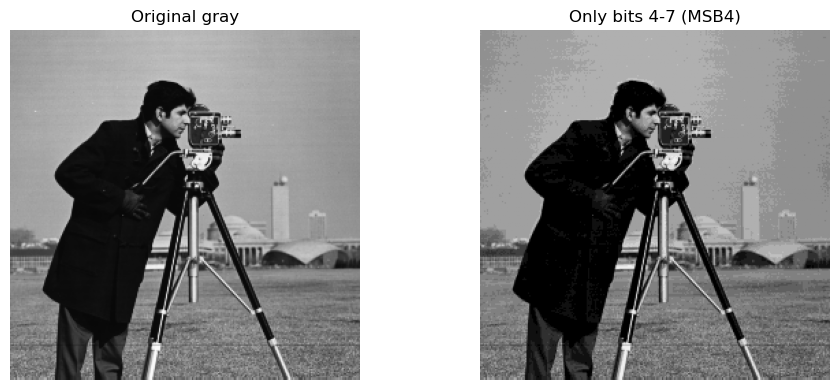

In [39]:
# EXERCISE 25 - write your Python code below
#
# Required operations:
# 1. Reconstruct the image from all values in `bit_planes` by multiplying each plane by `2**k`; store
# the result as `reconstructed`.
# 2. Create `msb4` by keeping only bits 4-7 of `gray` using mask `0b11110000`.
# 3. Verify that all-plane reconstruction equals `gray` exactly.
# 4. Display the original and the four-MSB reconstruction side by side.
#
# Write your code below this line.


reconstructed = sum(bit_planes[k].astype(np.uint16) * (2 ** k) for k in range(8)).astype(np.uint8)
msb4 = (gray & 0b11110000).astype(np.uint8)

print('all-plane reconstruction equals gray:', np.array_equal(reconstructed, gray))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original gray')
axes[0].axis('off')
axes[1].imshow(msb4, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Only bits 4-7 (MSB4)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


# 9. LSB steganography using MATLAB `cameraman.tif`

We will hide a short text message in the **least significant bit** of a grayscale image.

The procedure is:

1. encode the text as bytes;
2. prepend a 32-bit message-length header;
3. convert the bytes to a bit stream;
4. clear the LSB of selected pixels;
5. write the message bits into those LSBs;
6. reverse the process to recover the text.

Only the pixel values that carry a message bit can change, and each change is at most 1 intensity level.

> **File-format warning:** Save LSB steganography results in a **lossless** format such as PNG. JPEG compression can alter LSB values and destroy the hidden data.

In [40]:
# EXERCISE 26 - write your Python code below
#
# Required operations:
# 1. Define `text_to_bits(text)` to UTF-8 encode text, prepend a 4-byte big-endian length header, and
# return an unpacked bit array.
# 2. Define `embed_lsb(gray_u8, text)` to validate a 2-D uint8 image, clear the required LSBs, insert
# the payload bits, and return the stego image.
# 3. Define `extract_lsb(stego_u8)` to read the 32-bit length header, recover the payload bits, repack
# bytes, and decode UTF-8 text.
# 4. Include a capacity check before embedding so messages that are too long raise a clear error.
#
# Write your code below this line.


def text_to_bits(text):
    payload = text.encode('utf-8')
    header = len(payload).to_bytes(4, byteorder='big')
    data = np.frombuffer(header + payload, dtype=np.uint8)
    return np.unpackbits(data)


def embed_lsb(gray_u8, text):
    if gray_u8.ndim != 2 or gray_u8.dtype != np.uint8:
        raise ValueError('gray_u8 must be a 2-D uint8 image')

    bits = text_to_bits(text)
    if bits.size > gray_u8.size:
        raise ValueError(f'Message too long: need {bits.size} bits, capacity is {gray_u8.size}')

    stego = gray_u8.copy().ravel()
    stego[:bits.size] = (stego[:bits.size] & 0xFE) | bits
    return stego.reshape(gray_u8.shape)


def extract_lsb(stego_u8):
    flat = stego_u8.ravel()
    header_bits = (flat[:32] & 1).astype(np.uint8)
    length = int.from_bytes(np.packbits(header_bits).tobytes(), byteorder='big')

    total_bits = 32 + length * 8
    payload_bits = (flat[32:total_bits] & 1).astype(np.uint8)
    payload = np.packbits(payload_bits).tobytes()[:length]
    return payload.decode('utf-8')


print('LSB helpers ready: text_to_bits, embed_lsb, extract_lsb')


LSB helpers ready: text_to_bits, embed_lsb, extract_lsb


In [41]:
# EXERCISE 27 - write your Python code below
#
# Required operations:
# 1. Create a short string `secret_message`.
# 2. Call `embed_lsb(gray, secret_message)` to create `stego`.
# 3. Recover the text with `extract_lsb(stego)` into `recovered_message`.
# 4. Print original/recovered messages and verify they are equal.
#
# Write your code below this line.


secret_message = 'COM0418 Image Processing - Week 2 LSB demo'

stego = embed_lsb(gray, secret_message)
recovered_message = extract_lsb(stego)

print('original :', secret_message)
print('recovered:', recovered_message)
print('equal    :', secret_message == recovered_message)


original : COM0418 Image Processing - Week 2 LSB demo
recovered: COM0418 Image Processing - Week 2 LSB demo
equal    : True


## 9.1 Measure and visualize the change

Because only the LSB is modified, the absolute difference should be 0 or 1. The displayed difference is multiplied by 255 only to make changed pixels visible.

changed pixels: 182
max abs change: 1
MSE           : 0.002777099609375
PSNR          : 73.69488903506534


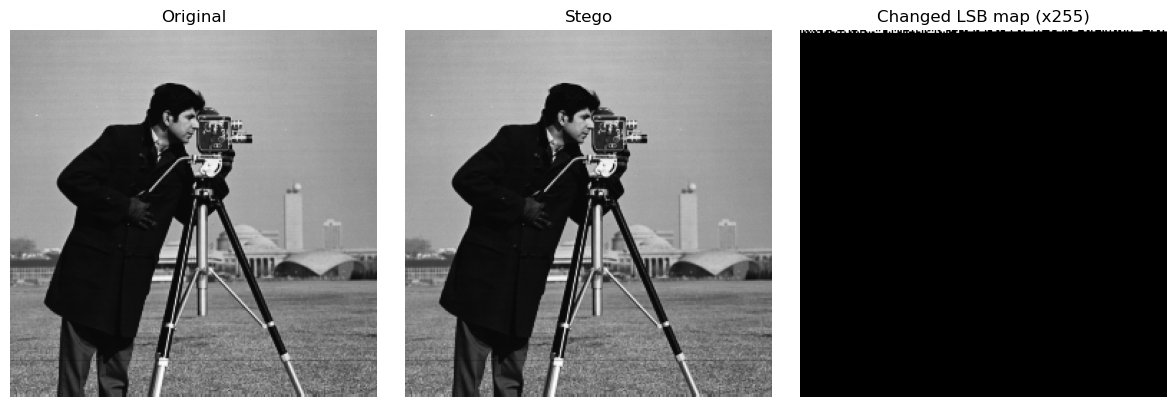

In [42]:
# EXERCISE 28 - write your Python code below
#
# Required operations:
# 1. Compute absolute pixel difference `diff` between `gray` and `stego` with `cv2.absdiff`.
# 2. Count changed pixels, compute MSE, and compute PSNR for 8-bit images.
# 3. Print changed-pixel count, maximum absolute change, MSE, and PSNR.
# 4. Display original, stego, and an amplified (`diff * 255`) map of changed LSB locations in a 1x3
# figure.
#
# Write your code below this line.


diff = cv2.absdiff(gray, stego)

changed = int(np.count_nonzero(diff))
max_abs = int(diff.max())
mse = float(np.mean(diff.astype(np.float64) ** 2))
psnr = float('inf') if mse == 0 else 10.0 * np.log10((255.0 ** 2) / mse)

print('changed pixels:', changed)
print('max abs change:', max_abs)
print('MSE           :', mse)
print('PSNR          :', psnr)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(stego, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Stego')
axes[1].axis('off')
axes[2].imshow(diff * 255, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Changed LSB map (x255)')
axes[2].axis('off')
plt.tight_layout()
plt.show()


## 9.2 Compare the LSB planes before and after embedding

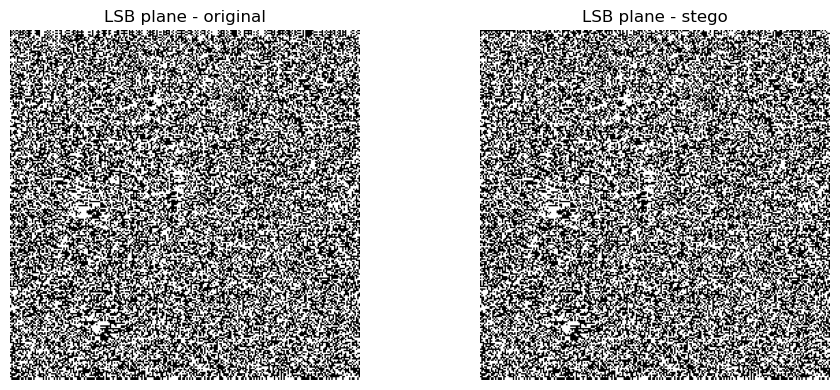

Embedding is only locally visible in the LSB plane; the full grayscale image still looks almost unchanged.


In [43]:
# EXERCISE 29 - write your Python code below
#
# Required operations:
# 1. Extract the original and stego LSB planes as `lsb_original = gray & 1` and `lsb_stego = stego &
# 1`.
# 2. Display both LSB planes side by side with grayscale range 0-1.
# 3. Observe whether the text embedding is visually obvious from the LSB-plane images.
#
# Write your code below this line.


lsb_original = gray & 1
lsb_stego = stego & 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(lsb_original, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('LSB plane - original')
axes[0].axis('off')
axes[1].imshow(lsb_stego, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('LSB plane - stego')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('Embedding is only locally visible in the LSB plane; the full grayscale image still looks almost unchanged.')


## 9.3 Save and reload the stego image

PNG is lossless, so the hidden message survives a normal save/read cycle.

In [44]:
# EXERCISE 30 - write your Python code below
#
# Required operations:
# 1. Save `stego` losslessly as `cameraman_stego.png` inside `OUTPUT_DIR` using `cv2.imwrite`.
# 2. Reload the file as grayscale into `stego_reloaded`.
# 3. Use `extract_lsb(stego_reloaded)` and print the recovered text to verify that PNG preserved the
# hidden bits.
#
# Write your code below this line.


stego_path = OUTPUT_DIR / 'cameraman_stego.png'
ok = cv2.imwrite(str(stego_path), stego)
print('write succeeded:', ok)

stego_reloaded = cv2.imread(str(stego_path), cv2.IMREAD_GRAYSCALE)
if stego_reloaded is None:
    raise RuntimeError(f'Failed to reload stego image: {stego_path}')

recovered_from_png = extract_lsb(stego_reloaded)
print('recovered from PNG:', recovered_from_png)
print('matches secret     :', recovered_from_png == secret_message)


write succeeded: True
recovered from PNG: COM0418 Image Processing - Week 2 LSB demo
matches secret     : True


# 10. Laboratory review and extension exercises

Before leaving the laboratory, make sure you can explain each of the following:

1. Why is `baby.jpg` displayed with wrong colors if the OpenCV BGR array is passed directly to `plt.imshow`?
2. What is the difference between a grayscale image and the thresholded binary version of `cameraman.tif`?
3. Why is Pillow more useful than ordinary `cv2.imread` when examining the index array and palette of `trees.tif`?
4. What is the difference between changing a NumPy data type and changing the numeric range?
5. Why can `uint8` NumPy arithmetic overflow or wrap around, while `cv2.add` saturates?
6. Which bit planes of `cameraman.tif` contain the strongest visible structure?
7. Why should an LSB stego image be stored in PNG rather than JPEG?
8. What channel-order difference exists between OpenCV (`baby.jpg`) and Pillow (`sherlock.jpg`)?

### Suggested extra work

- Change the threshold used to create the binary version of `cameraman.tif` and observe the result.
- Display `baby.jpg` once without BGR-to-RGB conversion and once with the correct conversion.
- Inspect a small region of the `trees.tif` index array and identify the corresponding palette colors.
- Reconstruct `cameraman.tif` using only bit planes 5, 6, and 7.
- Hide a different short message in the LSB of `cameraman.tif` and compare the number of changed pixels.
- Try writing the stego image as JPEG and test whether the hidden message survives.

## Review answers

**1. Wrong colors with OpenCV BGR + `plt.imshow`**  
OpenCV stores color as **BGR**. Matplotlib expects **RGB**. Passing `img_bgr` directly swaps red and blue. Fix with `cv2.cvtColor(..., COLOR_BGR2RGB)` or `img_bgr[:, :, ::-1]`.

**2. Grayscale vs binary `cameraman.tif`**  
Grayscale keeps many intensity levels (0–255). A thresholded binary image keeps only two values (0/255 or 0/1): pixels above the threshold become white, the rest black. Soft tones and fine detail are lost.

**3. Why Pillow for `trees.tif` indexed/palette**  
Pillow can keep mode `P`, expose the **index array**, and return the **palette** via `getpalette()`. Ordinary `cv2.imread(..., IMREAD_COLOR)` expands the palette to a BGR color image, so the index+colormap structure is no longer visible.

**4. Changing dtype vs changing numeric range**  
`astype(np.float32)` only changes the type; values can still be ~0–255. Normalization (`/ 255.0`) changes the **range** to ~0–1. Type conversion and scaling are different operations.

**5. NumPy wrap-around vs `cv2.add` saturation**  
`uint8` NumPy arithmetic is modular: `250 + 20 → 14`. `cv2.add` saturates at 255: `250 + 20 → 255`.

**6. Strongest visible bit planes**  
High-order planes (**bits 5–7 / MSB**) carry the strongest structure. The LSB (bit 0) looks noisy and holds little recognizable shape.

**7. Why PNG for LSB stego, not JPEG**  
LSB hiding depends on exact bit values. **PNG is lossless** and preserves them. **JPEG is lossy** and can corrupt LSBs, destroying the hidden message.

**8. OpenCV vs Pillow channel order**  
OpenCV (`baby.jpg`) → **BGR**. Pillow (`sherlock.jpg`) → **RGB**. The file is not “BGR”; the libraries decode channels in different orders.

## Extra work solutions

Run the cells below after the earlier exercises (they reuse `gray`, `img_bgr`, `index_array`, `indexed_pil`, `bit_planes`, `embed_lsb`, `OUTPUT_DIR`, `secret_message`, `stego`).

In [ ]:
# Extra 1 - different thresholds on cameraman.tif
for t in [50, 127, 200]:
    _, b = cv2.threshold(gray, t, 255, cv2.THRESH_BINARY)
    plt.figure(figsize=(4, 4))
    plt.imshow(b, cmap='gray', vmin=0, vmax=255)
    plt.title(f'threshold = {t}')
    plt.axis('off')
    plt.show()

print('Lower threshold -> more white; higher threshold -> more black.')


In [ ]:
# Extra 2 - baby.jpg without / with BGR->RGB conversion
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_bgr)
axes[0].set_title('Wrong: BGR direct')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title('Correct: BGR -> RGB')
axes[1].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Extra 3 - trees.tif index ROI and matching palette colors
roi_idx = index_array[0:5, 0:5]
print('index ROI:\n', roi_idx)

palette = indexed_pil.getpalette()
for idx in np.unique(roi_idx):
    i = int(idx) * 3
    rgb = tuple(palette[i:i+3])
    print(f'index {idx} -> RGB {rgb}')


In [ ]:
# Extra 4 - reconstruct cameraman.tif using only bits 5, 6, 7
msb3 = (
    bit_planes[5].astype(np.uint16) * (2 ** 5) +
    bit_planes[6].astype(np.uint16) * (2 ** 6) +
    bit_planes[7].astype(np.uint16) * (2 ** 7)
).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(msb3, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Only bits 5-7')
axes[1].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Extra 5 - different message lengths vs changed pixels
msg_a = 'Hi'
msg_b = 'Longer secret message for COM0418'

stego_a = embed_lsb(gray, msg_a)
stego_b = embed_lsb(gray, msg_b)

changed_a = int(np.count_nonzero(cv2.absdiff(gray, stego_a)))
changed_b = int(np.count_nonzero(cv2.absdiff(gray, stego_b)))

print('changed (short):', changed_a)
print('changed (long) :', changed_b)
print('Longer message usually changes more pixels (only when original LSB differs).')


In [ ]:
# Extra 6 - save stego as JPEG and test whether the message survives
jpg_path = OUTPUT_DIR / 'cameraman_stego.jpg'
cv2.imwrite(str(jpg_path), stego, [int(cv2.IMWRITE_JPEG_QUALITY), 95])

stego_jpg = cv2.imread(str(jpg_path), cv2.IMREAD_GRAYSCALE)

try:
    recovered_jpg = extract_lsb(stego_jpg)
    print('JPEG recovered:', recovered_jpg)
    print('survived:', recovered_jpg == secret_message)
except Exception as e:
    print('JPEG extraction failed:', type(e).__name__, e)

print('JPEG is lossy, so LSB payload is often destroyed. Prefer PNG for stego images.')
